In [ ]:
import pandas as pd
import numpy as np

In [ ]:
customers = pd.read_csv("/content/olist_customers_dataset.csv")
orders = pd.read_csv("/content/olist_orders_dataset.csv")
order_items = pd.read_csv("/content/olist_order_items_dataset.csv")
products = pd.read_csv("/content/olist_products_dataset.csv")
payments = pd.read_csv("/content/olist_order_payments_dataset.csv")
reviews = pd.read_csv("/content/olist_order_reviews_dataset.csv")

In [ ]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [ ]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [ ]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [ ]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [ ]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [ ]:
customers.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')

In [ ]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [ ]:
order_items.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')

In [ ]:
products.columns

Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')

In [ ]:
customer_orders = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

In [ ]:
customer_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [ ]:
customer_orders.shape

(99441, 12)

In [ ]:
full_data = customer_orders.merge(
    order_items,
    on="order_id",
    how="left"
)

In [ ]:
full_data.shape

(113425, 18)

In [ ]:
full_data.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


In [ ]:
full_data[["price", "freight_value"]].describe()

,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


In [ ]:
total_revenue = full_data["price"].sum()

total_revenue

np.float64(13591643.7)

In [ ]:
average_order_value = full_data.groupby("order_id")["price"].sum().mean()

average_order_value

np.float64(136.68048088816485)

In [ ]:
full_data["price"].sum()

np.float64(13591643.7)

In [ ]:
full_data = full_data.merge(
    products,
    on="product_id",
    how="left"
)

In [ ]:
full_data.shape

(113425, 26)

In [ ]:
full_data[[
    "product_category_name",
    "price"
]].head()

,product_category_name,price
0,utilidades_domesticas,29.99
1,perfumaria,118.70
2,automotivo,159.90
3,pet_shop,45.00
4,papelaria,19.90


In [ ]:
full_data["product_category_name"].value_counts().head(10)

,count
product_category_name,
cama_mesa_banho,11115
beleza_saude,9670
esporte_lazer,8641
moveis_decoracao,8334
informatica_acessorios,7827
utilidades_domesticas,6964
relogios_presentes,5991
telefonia,4545
ferramentas_jardim,4347


In [ ]:
category_revenue = full_data.groupby(
    "product_category_name"
)["price"].sum().sort_values(ascending=False)

category_revenue.head(10)

,price
product_category_name,
beleza_saude,1258681.34
relogios_presentes,1205005.68
cama_mesa_banho,1036988.68
esporte_lazer,988048.97
informatica_acessorios,911954.32
moveis_decoracao,729762.49
cool_stuff,635290.85
utilidades_domesticas,632248.66
automotivo,592720.11


In [ ]:
category_orders = full_data.groupby(
    "product_category_name"
)["order_id"].nunique().sort_values(ascending=False)

category_orders.head(10)

,order_id
product_category_name,
cama_mesa_banho,9417
beleza_saude,8836
esporte_lazer,7720
informatica_acessorios,6689
moveis_decoracao,6449
utilidades_domesticas,5884
relogios_presentes,5624
telefonia,4199
automotivo,3897


In [ ]:
full_data["product_category_name"].unique()[:10]


array(['utilidades_domesticas', 'perfumaria', 'automotivo', 'pet_shop',
       'papelaria', nan, 'moveis_decoracao', 'moveis_escritorio',
       'ferramentas_jardim', 'informatica_acessorios'], dtype=object)

In [ ]:
category_revenue_df = category_revenue.reset_index()
category_revenue_df.rename(columns={"price": "category_total_revenue"}, inplace=True)

full_data = full_data.merge(
    category_revenue_df,
    on="product_category_name",
    how="left"
)

In [ ]:
product_category_translation = pd.read_csv('/content/product_category_name_translation.csv')

full_data = full_data.merge(
    product_category_translation,
    on='product_category_name',
    how='left'
)

full_data[[
    "product_category_name",
    "product_category_name_english"
]].head()

,product_category_name,product_category_name_english
0,utilidades_domesticas,housewares
1,perfumaria,perfumery
2,automotivo,auto
3,pet_shop,pet_shop
4,papelaria,stationery


In [ ]:
category_revenue = full_data.groupby(
    "product_category_name_english"
)["price"].sum().sort_values(ascending=False)

category_revenue.head(10)

,price
product_category_name_english,
health_beauty,1258681.34
watches_gifts,1205005.68
bed_bath_table,1036988.68
sports_leisure,988048.97
computers_accessories,911954.32
furniture_decor,729762.49
cool_stuff,635290.85
housewares,632248.66
auto,592720.11


In [ ]:
avg_category_price = full_data.groupby(
    "product_category_name_english"
)["price"].mean().sort_values(ascending=False)

avg_category_price.head(10)

,price
product_category_name_english,
computers,1098.340542
small_appliances_home_oven_and_coffee,624.285658
home_appliances_2,476.124958
agro_industry_and_commerce,342.124858
musical_instruments,281.616000
small_appliances,280.778468
fixed_telephony,225.693182
construction_tools_safety,208.992371
watches_gifts,201.135984


In [ ]:
customer_orders_count = full_data.groupby(
    "customer_unique_id"
)["order_id"].nunique()

In [ ]:
customer_orders_count.describe()

,order_id
count,96096.000000
mean,1.034809
std,0.214384
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,17.000000


In [ ]:
customer_orders_count.value_counts().head(10)

,count
order_id,
1,93099
2,2745
3,203
4,30
5,8
6,6
7,3
9,1
17,1


In [ ]:
repeat_customers = customer_orders_count[
    customer_orders_count > 1
].count()

total_customers = customer_orders_count.count()

repeat_rate = (repeat_customers / total_customers) * 100

repeat_rate

np.float64(3.1187562437562435)

In [ ]:
reviews["review_score"].value_counts().sort_index()

,count
review_score,
1,11424
2,3151
3,8179
4,19142
5,57328


In [ ]:
reviews["review_score"].mean()

np.float64(4.08642062404257)

In [ ]:
orders[[
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]].head()

,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date
0,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18 00:00:00
1,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13 00:00:00
2,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04 00:00:00
3,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15 00:00:00
4,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"]
)

In [ ]:
orders["delivery_time"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.days

In [ ]:
orders["delivery_time"].describe()

,delivery_time
count,96476.000000
mean,12.094086
std,9.551746
min,0.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,209.000000


In [ ]:
review_delivery = orders.merge(
    reviews,
    on="order_id",
    how="inner"
)

In [ ]:
review_delivery[[
    "delivery_time",
    "review_score"
]].head()

,delivery_time,review_score
0,8.0,4
1,13.0,4
2,9.0,5
3,13.0,5
4,2.0,5


In [ ]:
review_delivery.groupby("review_score")[
    "delivery_time"
].mean()

,delivery_time
review_score,
1,20.849825
2,16.194832
3,13.795278
4,11.848054
5,10.224097


In [ ]:
import matplotlib.pyplot as plt

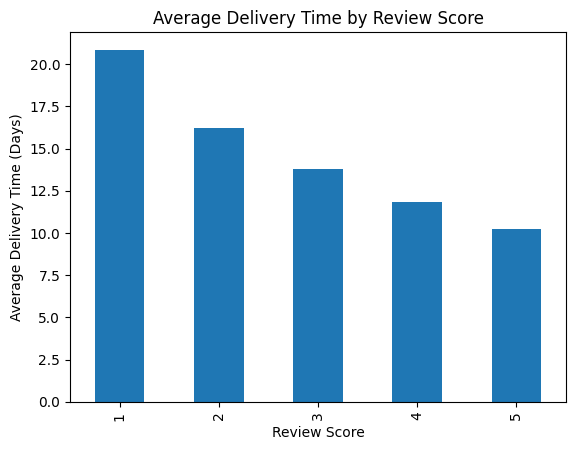

In [ ]:
review_delivery.groupby("review_score")[
    "delivery_time"
].mean().plot(kind="bar")

plt.title("Average Delivery Time by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Average Delivery Time (Days)")

plt.show()

In [ ]:
top_categories = category_revenue.head(10)

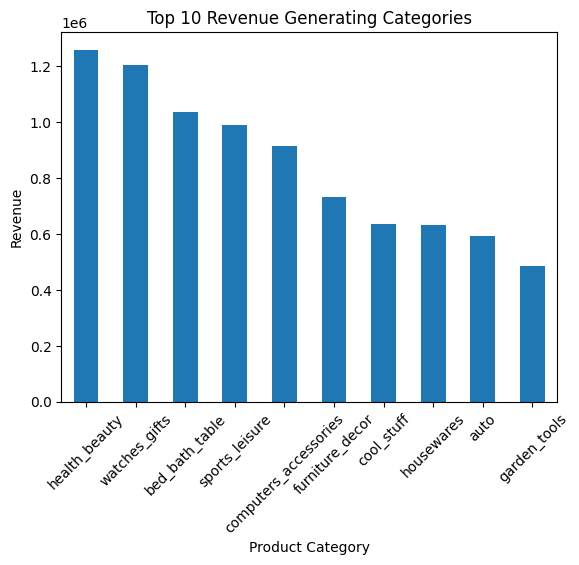

In [ ]:
top_categories.plot(kind="bar")

plt.title("Top 10 Revenue Generating Categories")
plt.xlabel("Product Category")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

In [ ]:
full_data["order_purchase_timestamp"] = pd.to_datetime(
    full_data["order_purchase_timestamp"]
)

In [ ]:
full_data["purchase_month"] = full_data[
    "order_purchase_timestamp"
].dt.to_period("M")

In [ ]:
monthly_revenue = full_data.groupby(
    "purchase_month"
)["price"].sum()

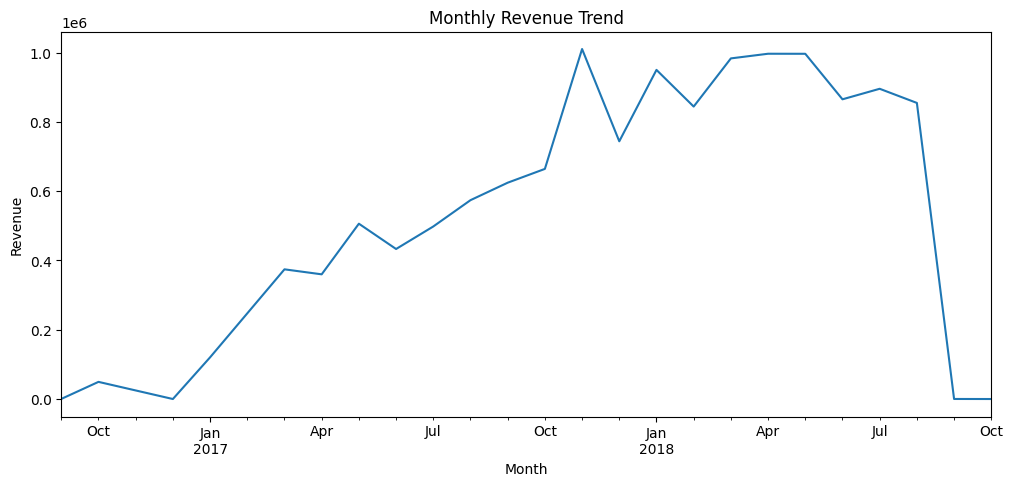

In [ ]:
monthly_revenue.plot(figsize=(12,5))

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

In [ ]:
monthly_orders = full_data.groupby(
    "purchase_month"
)["order_id"].nunique()

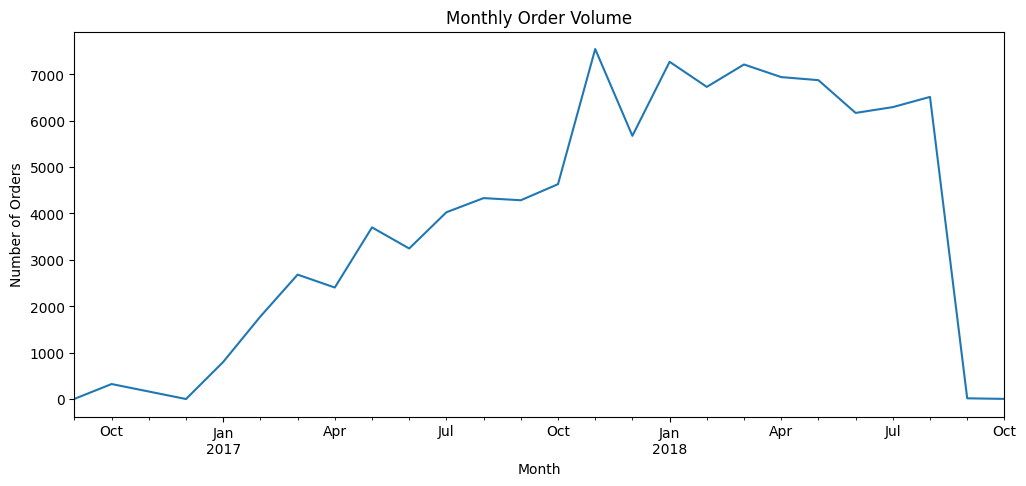

In [ ]:
monthly_orders.plot(figsize=(12,5))

plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.show()

In [ ]:
customer_purchase = full_data.groupby(
    "customer_unique_id"
)["order_purchase_timestamp"].min()

In [ ]:
customer_purchase = customer_purchase.dt.to_period("M")

In [ ]:
customer_purchase.head()

,order_purchase_timestamp
customer_unique_id,
0000366f3b9a7992bf8c76cfdf3221e2,2018-05
0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05
0000f46a3911fa3c0805444483337064,2017-03
0000f6ccb0745a6a4b88665a16c9f078,2017-10
0004aac84e0df4da2b147fca70cf8255,2017-11


In [ ]:
full_data["purchase_month"] = full_data[
    "order_purchase_timestamp"
].dt.to_period("M")

In [ ]:
full_data["cohort_month"] = full_data[
    "customer_unique_id"
].map(customer_purchase)

In [ ]:
full_data["cohort_index"] = (
    (full_data["purchase_month"].dt.year - full_data["cohort_month"].dt.year) * 12
    +
    (full_data["purchase_month"].dt.month - full_data["cohort_month"].dt.month)
)

In [ ]:
full_data[[
    "customer_unique_id",
    "cohort_month",
    "purchase_month",
    "cohort_index"
]].head()

,customer_unique_id,cohort_month,purchase_month,cohort_index
0,7c396fd4830fd04220f754e42b4e5bff,2017-09,2017-10,1
1,af07308b275d755c9edb36a90c618231,2018-07,2018-07,0
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08,2018-08,0
3,7c142cf63193a1473d2e66489a9ae977,2017-11,2017-11,0
4,72632f0f9dd73dfee390c9b22eb56dd6,2018-02,2018-02,0


In [ ]:
full_data["cohort_index"].value_counts().sort_index().head(10)

,count
cohort_index,
0,110963
1,571
2,390
3,257
4,231
5,173
6,170
7,138
8,105


In [ ]:
cohort_data = full_data.groupby(
    ["cohort_month", "cohort_index"]
)["customer_unique_id"].nunique().reset_index()

In [ ]:
cohort_pivot = cohort_data.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="customer_unique_id"
)

In [ ]:
cohort_pivot.head()

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,321.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,2.0
2016-12,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,764.0,3.0,2.0,1.0,3.0,1.0,4.0,1.0,1.0,NaN,3.0,1.0,6.0,3.0,1.0,1.0,2.0,3.0,1.0,NaN
2017-02,1752.0,4.0,5.0,2.0,7.0,2.0,4.0,3.0,3.0,4.0,2.0,5.0,3.0,3.0,2.0,1.0,1.0,4.0,NaN,NaN


In [ ]:
cohort_size = cohort_pivot[0]

In [ ]:
retention_matrix = cohort_pivot.divide(
    cohort_size,
    axis=0
)

In [ ]:
retention_matrix.head()

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,1.0,NaN,NaN,NaN,NaN,NaN,0.003115,NaN,NaN,0.003115,NaN,0.003115,NaN,0.003115,NaN,0.003115,NaN,0.003115,0.006231,0.006231
2016-12,1.0,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,1.0,0.003927,0.002618,0.001309,0.003927,0.001309,0.005236,0.001309,0.001309,NaN,0.003927,0.001309,0.007853,0.003927,0.001309,0.001309,0.002618,0.003927,0.001309,NaN
2017-02,1.0,0.002283,0.002854,0.001142,0.003995,0.001142,0.002283,0.001712,0.001712,0.002283,0.001142,0.002854,0.001712,0.001712,0.001142,0.000571,0.000571,0.002283,NaN,NaN


In [ ]:
import seaborn as sns

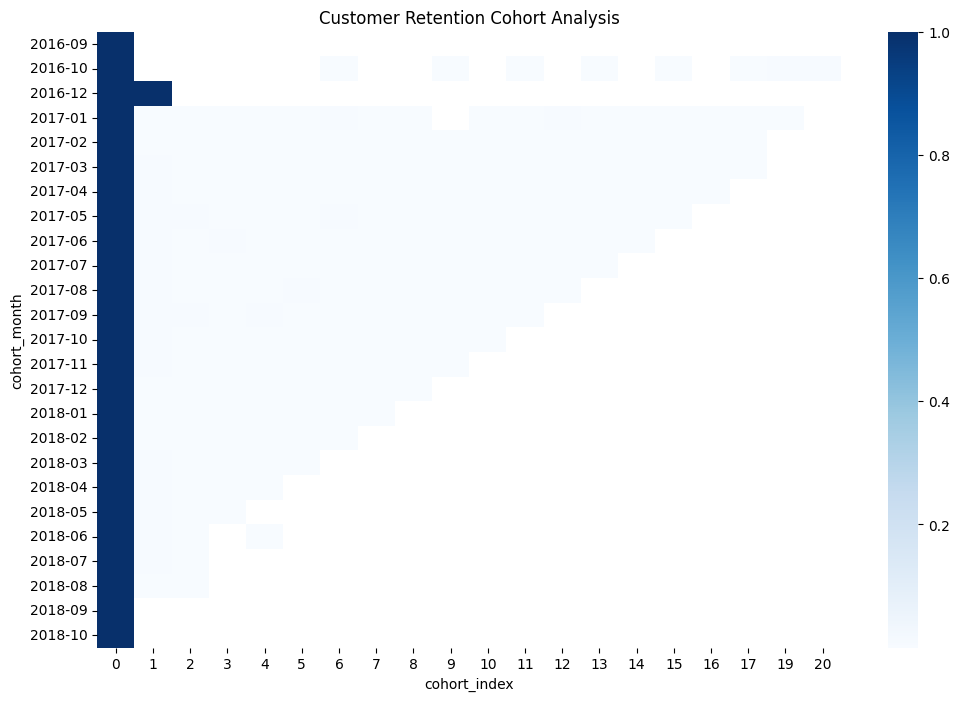

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    retention_matrix,
    annot=False,
    cmap="Blues"
)

plt.title("Customer Retention Cohort Analysis")

plt.show()

In [ ]:
full_data[[
    "customer_city",
    "customer_state"
]].head()

,customer_city,customer_state
0,sao paulo,SP
1,barreiras,BA
2,vianopolis,GO
3,sao goncalo do amarante,RN
4,santo andre,SP


In [ ]:
state_revenue = full_data.groupby(
    "customer_state"
)["price"].sum().sort_values(ascending=False)

In [ ]:
state_revenue.head(10)

,price
customer_state,
SP,5202955.05
RJ,1824092.67
MG,1585308.03
RS,750304.02
PR,683083.76
SC,520553.34
BA,511349.99
DF,302603.94
GO,294591.95


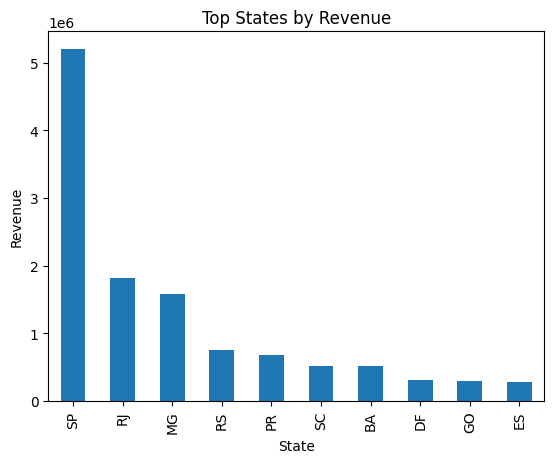

In [ ]:
state_revenue.head(10).plot(kind="bar")

plt.title("Top States by Revenue")
plt.xlabel("State")
plt.ylabel("Revenue")

plt.show()

In [ ]:
full_data.to_csv(
    "ecommerce_full_data.csv",
    index=False
)

In [ ]:
full_data = full_data.merge(
    reviews[["order_id", "review_score"]],
    on="order_id",
    how="left"
)

In [ ]:
full_data = full_data.merge(
    orders[["order_id", "delivery_time"]],
    on="order_id",
    how="left"
)

In [ ]:
full_data[[
    "review_score",
    "delivery_time"
]].head()

,review_score,delivery_time
0,4.0,8.0
1,4.0,13.0
2,5.0,9.0
3,5.0,13.0
4,5.0,2.0


In [ ]:
full_data.to_csv(
    "ecommerce_full_data.csv",
    index=False
)